In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load Breast Cancer dataset

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset loaded successfully.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully.
Features shape: (569, 30)
Target shape: (569,)


In [3]:
# Display basic information about the dataset

print("First 5 rows:")
display(X.head())

print("\nDataset shape:")
print(X.shape)

print("\nData types:")
print(X.dtypes)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Dataset shape:
(569, 30)

Data types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave po

In [4]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [5]:
# Create Decision Tree using Gini impurity

dt_gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Train the model
dt_gini.fit(X_train, y_train)

# Predictions
y_pred_gini = dt_gini.predict(X_test)

# Accuracy
gini_accuracy = accuracy_score(y_test, y_pred_gini)

print("Decision Tree using Gini Impurity")
print("Accuracy:", gini_accuracy)

Decision Tree using Gini Impurity
Accuracy: 0.9122807017543859


In [6]:
# Create Decision Tree using entropy
# Entropy is used to calculate information gain

dt_entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

# Train the model
dt_entropy.fit(X_train, y_train)

# Predictions
y_pred_entropy = dt_entropy.predict(X_test)

# Accuracy
entropy_accuracy = accuracy_score(y_test, y_pred_entropy)

print("Decision Tree using Entropy / Information Gain")
print("Accuracy:", entropy_accuracy)

Decision Tree using Entropy / Information Gain
Accuracy: 0.9122807017543859


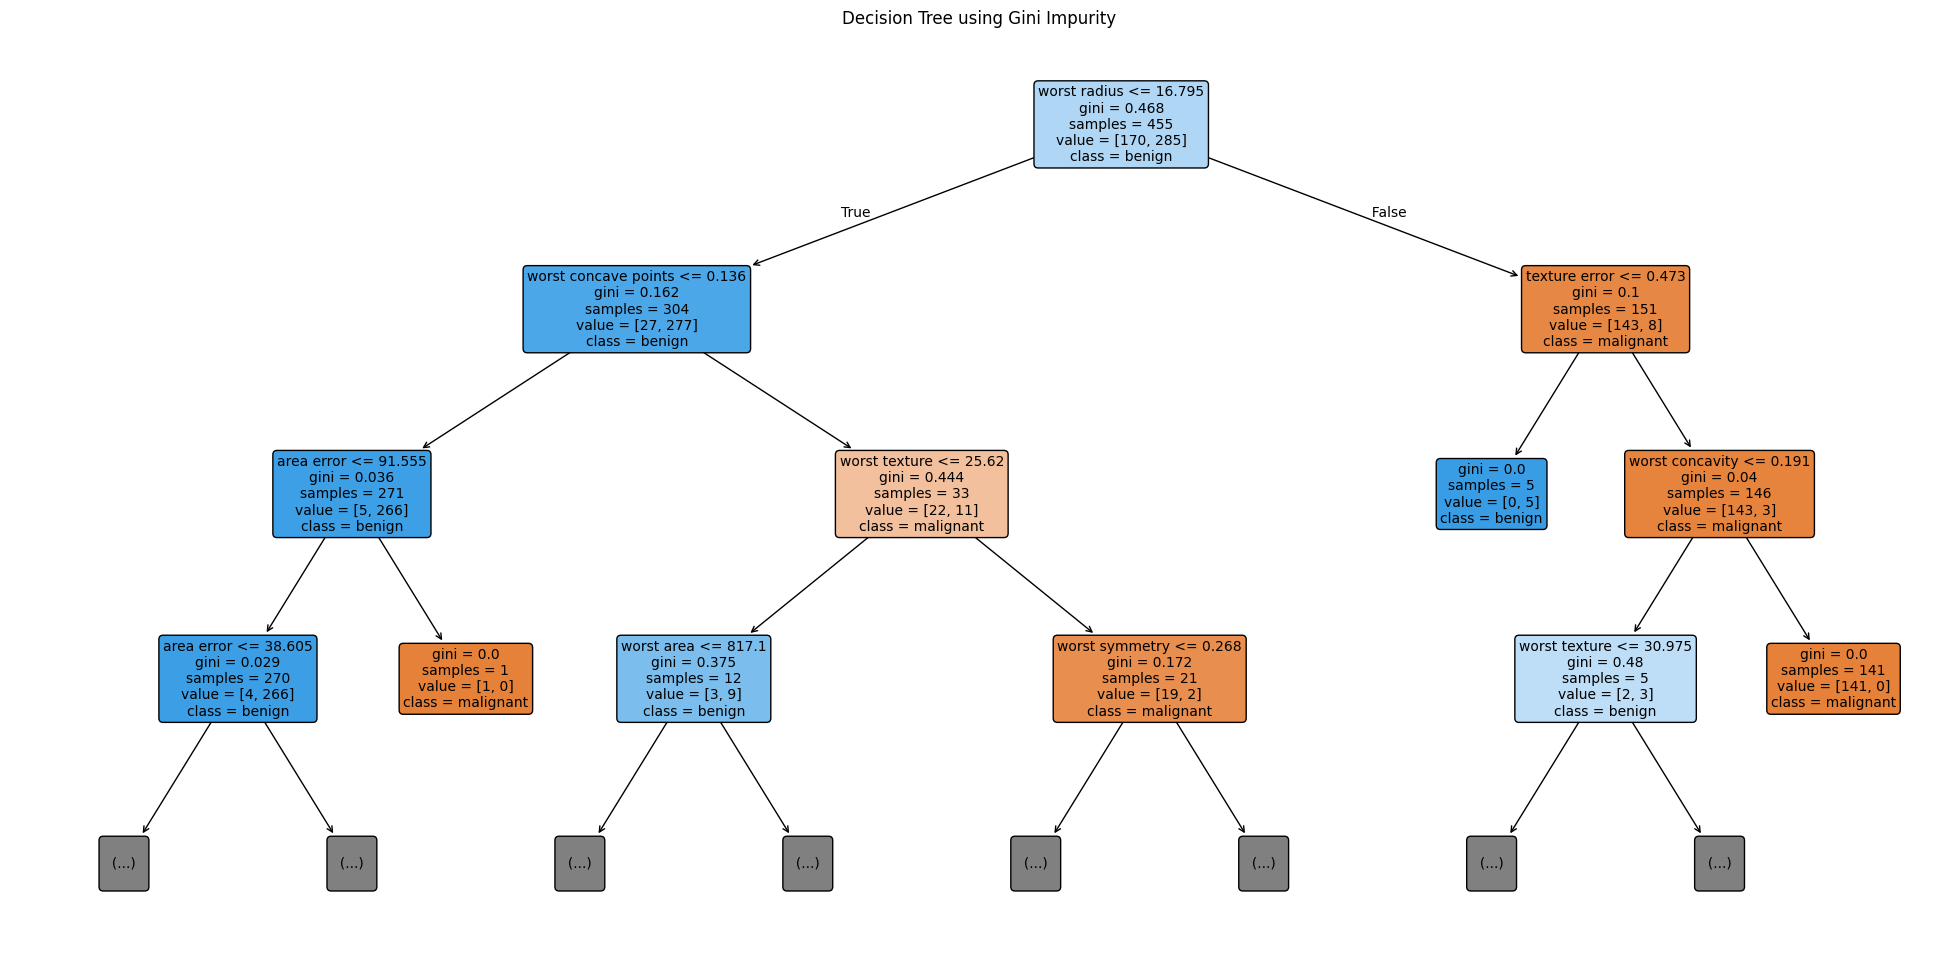

In [7]:
# Visualize the Decision Tree

plt.figure(figsize=(25, 12))

plot_tree(
    dt_gini,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree using Gini Impurity")
plt.show()

In [8]:
# Compare training and testing accuracy

train_accuracy = dt_gini.score(X_train, y_train)
test_accuracy = dt_gini.score(X_test, y_test)

print("Decision Tree - Overfitting Check")
print("----------------------------------")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Decision Tree - Overfitting Check
----------------------------------
Training Accuracy: 1.0
Testing Accuracy : 0.9122807017543859


In [9]:
# Define parameter combinations for tuning

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Create Decision Tree

dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

# Grid Search

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best cross-validation score:
0.9384615384615385


In [10]:
# Get the best Decision Tree

best_dt = grid_search.best_estimator_

# Predictions
y_pred_best_dt = best_dt.predict(X_test)

# Calculate metrics

dt_accuracy = accuracy_score(y_test, y_pred_best_dt)
dt_precision = precision_score(y_test, y_pred_best_dt)
dt_recall = recall_score(y_test, y_pred_best_dt)
dt_f1 = f1_score(y_test, y_pred_best_dt)

print("Tuned Decision Tree Results")
print("---------------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Tuned Decision Tree Results
---------------------------
Accuracy : 0.9385964912280702
Precision: 0.9577464788732394
Recall   : 0.9444444444444444
F1 Score : 0.951048951048951


In [11]:
# Create Random Forest classifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train Random Forest

rf.fit(X_train, y_train)

# Predictions

y_pred_rf = rf.predict(X_test)

# Metrics

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104


In [12]:
# Compare the two models

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.938596,0.957746,0.944444,0.951049
1,Random Forest,0.956140,0.958904,0.972222,0.965517


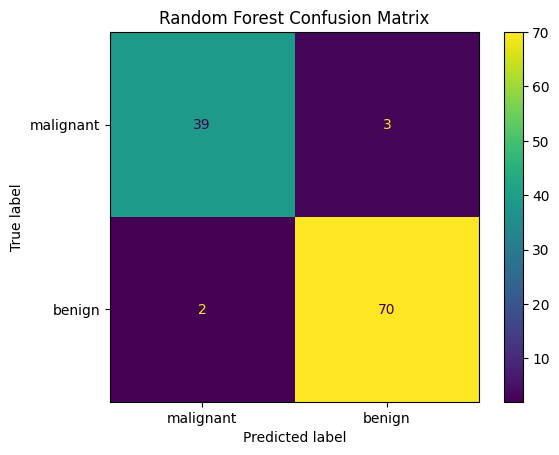

In [13]:
# Confusion Matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [14]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

# Sort by importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features

display(feature_importance.head(10))

,Feature,Importance
23,worst area,0.140016
27,worst concave points,0.129530
20,worst radius,0.097696
7,mean concave points,0.090885
22,worst perimeter,0.072226
2,mean perimeter,0.069574
0,mean radius,0.068676
6,mean concavity,0.057638
3,mean area,0.049172
26,worst concavity,0.034340


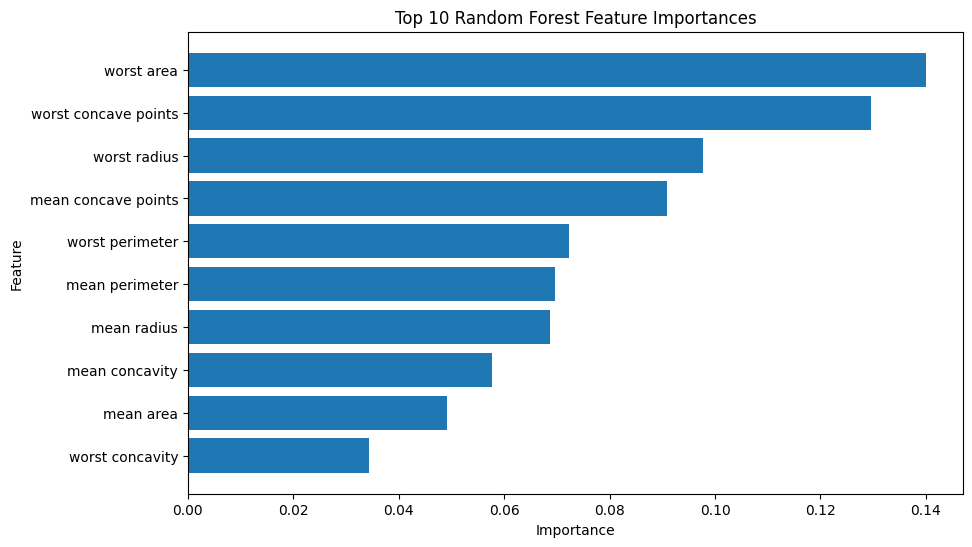

In [15]:
# Plot top 10 important features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.show()

In [16]:
# Detailed classification report for Random Forest

print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=data.target_names
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [17]:
# Install MLflow

!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [18]:
import mlflow
import mlflow.sklearn

# Start an MLflow experiment

mlflow.set_experiment("W3D3_Decision_Trees_Random_Forests")

with mlflow.start_run(run_name="Random_Forest"):

    # Log parameters
    mlflow.log_param("model", "RandomForestClassifier")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("random_state", 42)

    # Log metrics
    mlflow.log_metric("accuracy", rf_accuracy)
    mlflow.log_metric("precision", rf_precision)
    mlflow.log_metric("recall", rf_recall)
    mlflow.log_metric("f1_score", rf_f1)

    # Log model
    mlflow.sklearn.log_model(
        rf,
        "random_forest_model"
    )

print("MLflow experiment completed successfully.")

2026/08/11 17:12:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/11 17:12:21 INFO mlflow.store.db.utils: Updating database tables
2026/08/11 17:12:25 INFO mlflow.tracking.fluent: Experiment with name 'W3D3_Decision_Trees_Random_Forests' does not exist. Creating a new experiment.
2026/08/11 17:12:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow experiment completed successfully.
